# Aufgabe 5 – Welche Zellsubsets wählen die Modelle aus?

## 1. Datenbasis

Wir interpretieren die gespeicherten **30 gemeinsamen Splits (0–29)** von CellCNN, Citrus und der linearen Single-Cell-SVM auf `gated_alive`. Voraussetzung sind vollständige Aufgabe-4-Exporte für diese Splits. Der Lauf prüft dies zuerst; ein noch laufender Citrus-Benchmark wird weder verändert noch automatisch durch eine kleinere Auswertung ersetzt.

Die vorhandene t-SNE-Karte aus Aufgabe 2 umfasst **500 Zellen je Spender, 20 Spender und 37 Marker**, bei Perplexität 30. Ihre Zell-IDs und Originalereignisse werden geprüft. Die Auswertung trainiert keine Klassifikatoren und rekonstruiert keine Citrus-Bäume. R wird nur für die vorhandene Konfigurationsprüfung über `ssbi-citrus` benötigt.


In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.task5_interpretation import run_interpretation

FIGURES = PROJECT_ROOT / "results" / "figures"


## 2. Auswahlregeln und Wiederkehr

**CellCNN:** Für jeden ausgewählten Filter berechnen wir die Antwort $r_{if}=\max(0,w_f^Tz_i+b_f)$. Die Referenz ist exakt die ursprüngliche Scaler-Stichprobe: 20.000 Zellen je tatsächlichem inneren Trainingsspender (9 oder 10 Spender), gezogen mit dem ursprünglichen Kandidatenseed. Die gespeicherte Modellskalierung bleibt unverändert. Der normierte Score $r_{if}/\max_j r_{jf}$ definiert mit Schwelle **größer als 0,5** das Subset. Filter mit Maximum oder Ausgangskontrast null wählen kein relevantes Subset. Dessen Zentroid ist der mittlere unstandardisierte `arcsinh(x/5)`-Markerwert der ausgewählten Referenzzellen. Gleiche Referenzzellzahlen verhindern eine Gewichtung nach FCS-Dateigröße; innerhalb des Subsets gehen alle ausgewählten Zellen gleich ein.

**Citrus:** Wir verwenden die gespeicherten Trainingszentroiden der Cluster mit $|\beta_j|>10^{-10}$. Der Regressionskoeffizient quantifiziert den Modellbezug und dessen Richtung. Ein dargestellter Zentroid steht für ein ausgewähltes Cluster; er ist keine neu zugeordnete Zellpopulation auf der Karte.

**Wiederkehr:** Die Zentroiden werden je Methode getrennt gruppiert. Für Gruppe $G$ ist

$$F_G=\frac{\#\{s\in\{0,\ldots,29\}:\text{mindestens ein Mitglied von }G\text{ in Split }s\}}{30}.$$

Nullmodelle bleiben im Nenner. Mehrere Gruppenmitglieder im selben Split zählen einmal. Wir zeigen Gruppen mit **mindestens sechs Vorkommen**. Positive und negative Mitglieder dürfen gemeinsam gruppiert werden; beide Richtungen werden in der Tabelle ausgewiesen. Der Repräsentant minimiert die Summe der Kosinusdistanzen innerhalb der Gruppe, bei Gleichstand nach Split- und Subset-ID.

Für die Gruppierung verwenden wir ausschließlich die gespeicherte explorative z-Skalierung aus Aufgabe 2 und **Average-Linkage mit Kosinusdistanz, Distanzschnitt 0,4**. Diese Regel übertragen wir aus der Filtergruppierung des [Originalcodes](https://github.com/eiriniar/CellCnn/tree/0413a9f49fe0831c8fe3280957fb341f9e028d2d/cellCnn); sie ist **keine belegte Originalparametrisierung der NK-Zentroidanalyse**. Die Zentroidanalyse selbst folgt dem [Paper, Methoden: NK-cell benchmark](../CellCNN.pdf). Der gemeinsame explorative Scaler geht nicht in Klassifikatorvorhersagen oder die CellCNN-Selektionsschwelle ein.

**SVM:** Die bisherige eigene Lösung bleibt erhalten. Pro vollständigem Testspender werden exakt die höchsten $\lceil0{,}01N_d\rceil$ Zellmargins ausgewählt; Gleichstände folgen der Originalereignisnummer. Innerhalb dieses Subsets entscheidet das Vorzeichen von $m_i-\tau_s$ über die Richtung. Für Karten-Zelle $i$ ist $f_i^\pm$ die Auswahlhäufigkeit über alle äußeren Testauftritte ihres Spenders innerhalb der 30 Splits. Gruppenhäufigkeiten $F_G$ und SVM-Zellhäufigkeiten $f_i^\pm$ beschreiben unterschiedliche Größen, keine vergleichbaren Effektstärken.


## 3. Ergebnisse

Die folgenden Tabellen und Abbildungen werden aus dem aktuellen Lauf erzeugt. Falls keine Gruppe die vorab festgelegte Schwelle erreicht, bleibt dies das Ergebnis; es wird kein Ersatzfilter anhand erwarteter Marker oder Modellgüte ausgesucht.


In [2]:
results = run_interpretation(PROJECT_ROOT)
centroids = results["centroids"]
groups = results["groups"]
svm_cells = results["svm_cells"]
representative = results["representative_cells"]
retained = groups.loc[groups.retained].copy()

for method in ["CellCNN", "Citrus"]:
    if retained.loc[retained.method.eq(method)].empty:
        display(Markdown(f"**{method}:** Keine Zentroidgruppe erreicht sechs von 30 Splits."))

display(retained.rename(columns={
    "method": "Methode", "group_id": "Gruppe", "n_centroids": "Zentroiden",
    "n_splits": "Ausgewertete Splits", "occurrences": "Vorkommen",
    "frequency": "Wiederkehr", "positive_splits": "Splits mit positiver Richtung",
    "negative_splits": "Splits mit negativer Richtung",
    "representative_split_id": "Repräsentant: Split",
    "representative_subset_id": "Repräsentant: Subset",
}).drop(columns="retained").round({"Wiederkehr": 3}))


Citrus-Konfiguration, Eingabeprüfsummen und Trainingscode stimmen.


,Methode,Gruppe,Zentroiden,Ausgewertete Splits,Vorkommen,Wiederkehr,Splits mit positiver Richtung,Splits mit negativer Richtung,Repräsentant: Split,Repräsentant: Subset
0,CellCNN,1,58,30,30,1.000,30,0,9,2
1,CellCNN,2,25,30,20,0.667,0,20,1,1
2,CellCNN,3,20,30,15,0.500,0,15,15,0
3,CellCNN,4,8,30,8,0.267,2,6,23,2
15,Citrus,1,28,30,18,0.600,18,0,25,139891
16,Citrus,2,19,30,11,0.367,11,0,12,139875
17,Citrus,3,17,30,10,0.333,4,7,3,139847
18,Citrus,4,6,30,6,0.200,0,6,8,139775
19,Citrus,5,7,30,6,0.200,6,0,20,139062


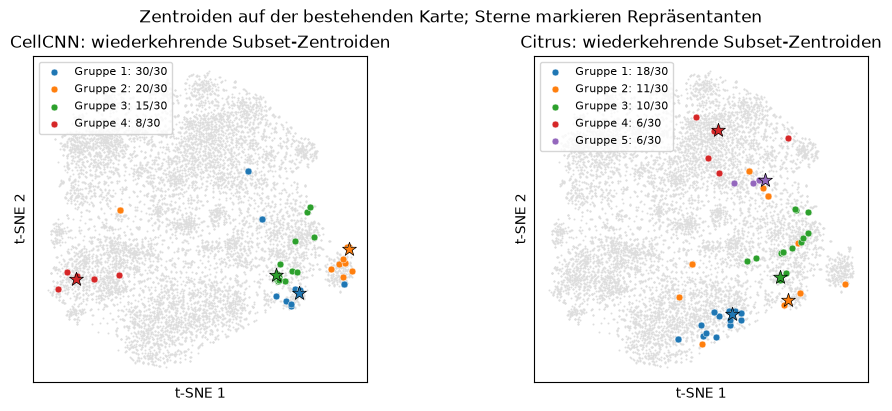

In [3]:
def background(ax, title):
    ax.scatter(svm_cells.component_1, svm_cells.component_2, s=2,
               color="#dddddd", linewidths=0, rasterized=True)
    ax.set(title=title, xlabel="t-SNE 1", ylabel="t-SNE 2", aspect="equal", xticks=[], yticks=[])

FIGURES.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for ax, method in zip(axes, ["CellCNN", "Citrus"]):
    background(ax, f"{method}: wiederkehrende Subset-Zentroiden")
    selected_groups = retained.loc[retained.method.eq(method)]
    for group in selected_groups.itertuples():
        frame = centroids.loc[centroids.method.eq(method) & centroids.group_id.eq(group.group_id)]
        color = plt.get_cmap("tab10")((group.group_id - 1) % 10)
        ax.scatter(frame.component_1, frame.component_2, s=24, color=color,
                   edgecolors="white", linewidths=.3,
                   label=f"Gruppe {group.group_id}: {group.occurrences}/30")
        point = frame.loc[frame.split_id.eq(group.representative_split_id) &
                          frame.subset_id.eq(group.representative_subset_id)].iloc[0]
        ax.scatter(point.component_1, point.component_2, s=110, marker="*",
                   color=color, edgecolors="black", linewidths=.5)
    if selected_groups.empty:
        ax.text(.5, .5, "Keine Gruppe mit mindestens 6 Vorkommen",
                transform=ax.transAxes, ha="center", bbox=dict(facecolor="white", alpha=.9))
    else:
        ax.legend(fontsize=8, loc="upper left")
fig.suptitle("Zentroiden auf der bestehenden Karte; Sterne markieren Repräsentanten")
fig.savefig(FIGURES / "task5_paper_centroids.png", dpi=180, bbox_inches="tight")
plt.show()


Der repräsentative Filter wählt **87 von 10000 Karten-Zellen** aus. Dies ist eine explorative Anwendung auf alle 20 Spender, einschließlich Trainingsspendern.

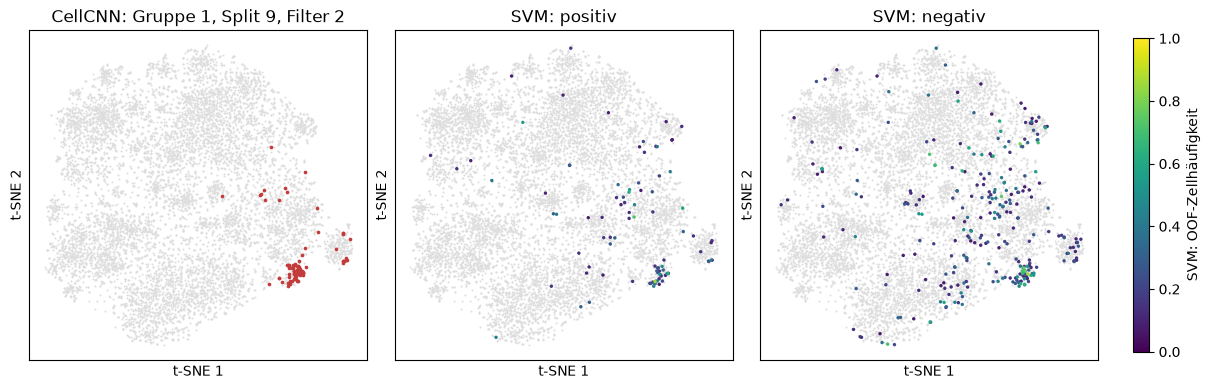

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")
background(axes[0], "CellCNN: repräsentatives Subset")
if representative.empty:
    axes[0].text(.5, .5, "Keine wiederkehrende CellCNN-Gruppe", transform=axes[0].transAxes,
                 ha="center", fontsize=9, bbox=dict(facecolor="white", alpha=.9))
else:
    chosen = representative.loc[representative.selected]
    axes[0].scatter(chosen.component_1, chosen.component_2, s=7, color="#c43b3b", linewidths=0)
    row = representative.iloc[0]
    axes[0].set_title(f"CellCNN: Gruppe {int(row.group_id)}, Split {int(row.split_id)}, Filter {int(row.subset_id)}")
    display(Markdown(f"Der repräsentative Filter wählt **{len(chosen)} von {len(representative)} Karten-Zellen** aus. "
                     "Dies ist eine explorative Anwendung auf alle 20 Spender, einschließlich Trainingsspendern."))
    if chosen.empty:
        axes[0].text(.5, .5, "Keine ausgewählten Karten-Zellen", transform=axes[0].transAxes,
                     ha="center", bbox=dict(facecolor="white", alpha=.9))
for ax, direction, label in zip(axes[1:], ["positive", "negative"], ["positiv", "negativ"]):
    background(ax, f"SVM: {label}")
    column = direction + "_frequency"
    selected = svm_cells.loc[svm_cells[column].gt(0)].sort_values(column)
    points = ax.scatter(selected.component_1, selected.component_2, c=selected[column],
                        cmap="viridis", vmin=0, vmax=1, s=6, linewidths=0, rasterized=True)
    if selected.empty:
        ax.text(.5, .5, "Keine ausgewählten Karten-Zellen", transform=ax.transAxes,
                ha="center", bbox=dict(facecolor="white", alpha=.9))
fig.colorbar(points, ax=axes[1:], label="SVM: OOF-Zellhäufigkeit", shrink=.8)
fig.savefig(FIGURES / "task5_paper_subsets.png", dpi=180, bbox_inches="tight")
plt.show()


## Einordnung des vollständigen Laufs vom 9. September 2026

Alle 30 Splits sind vollständig ausgewertet. Aus **130 CellCNN- und 123 Citrus-Zentroiden** erreichen vier beziehungsweise fünf Gruppen mindestens sechs Vorkommen. Die häufigste CellCNN-Gruppe tritt in **30/30**, die häufigste Citrus-Gruppe in **18/30** Splits auf; beide enthalten ausschließlich positive Mitglieder. Drei Citrus-Splits liefern keine wirksamen Cluster und bleiben im Nenner.

Der CellCNN-Repräsentant der häufigsten Gruppe (Split 9, Filter 2) wählt bei explorativer Anwendung auf alle Spender **87 Karten-Zellen** aus. Die SVM wählt **93 Karten-Zellen mindestens einmal positiv** und **286 mindestens einmal negativ** aus. Alle 20 Spender sind im Test vertreten, mit **vier bis 16 Testauftritten** je Spender. Die Häufigkeiten verwenden jeweils diesen spenderbezogenen Nenner.

Die unterschiedliche Wiederkehr und Zellzahl belegen keine biologische Überlegenheit einer Methode: Die Auswahlregeln und dargestellten Größen unterscheiden sich. Die Gruppen fassen modellassoziierte Markerprofile zusammen; weder Kartenlage noch Wiederkehr allein identifizieren einen biologischen Zelltyp.


## 4. Grenzen und Abweichungen

- **30 statt 100 Splits:** Sechs Vorkommen übertragen die 20-%-Schwelle des Papers; die Stabilitätsaussage ist wegen weniger und überlappender Wiederholungen begrenzt. Sie ist kein Signifikanztest.
- **Feste Trainingsreferenz:** Die CellCNN-Halbmaximum-Schwelle bezieht sich auf die ursprüngliche Scaler-Stichprobe, nicht auf sämtliche FCS-Ereignisse. Seltene Ereignisse außerhalb dieser Stichprobe können fehlen. Filterantworten außerhalb der Referenz können deren Maximum übersteigen.
- **Explorative Zentroidgruppen:** Gruppierung, Repräsentanten und ihre Darstellung fassen bereits trainierte Modelle zusammen. Sie liefern keine unabhängige Leistungsbewertung. Der Clusteringparameter wurde aus der Filtergruppierung übertragen, nicht anhand der resultierenden Zelltypen optimiert.
- **Darstellung:** Zentroiden werden über die nächstgelegene Karten-Zelle projiziert; das ist eine Approximation. Die kleine Kartenstichprobe kann seltene Subsets unvollständig zeigen. Bei Citrus markieren Punkte ausschließlich Clusterzentroiden. Die CellCNN-Darstellung ist eine illustrative Anwendung eines Repräsentanten, die SVM-Darstellung bleibt spenderweise OOF.
- **Aussage:** Wiederkehrende modellassoziierte Subsets sind weder eine exakte kausale Zerlegung der Vorhersage noch ein Beleg eines biologischen Zelltyps. Positive und negative Vorkommen einer Zentroidgruppe können sich überschneiden.

Die Ausgaben liegen unter `results/tables/task5_paper_*` und `results/figures/task5_paper_*`. Die bisherigen `task5_*`-Ergebnisse bleiben als historischer Stand erhalten. Der Kurzbericht verwendet ausschließlich die aktuellen `task5_paper_*`-Ergebnisse und prüft deren Quellen- und Ausgabeprüfsummen.
